In [1]:
# Import all libraries we'll need
import pandas as pd
import numpy as np

print("✅ All packages imported successfully!")
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)

✅ All packages imported successfully!
Pandas version: 3.0.3
NumPy version: 2.4.6


In [2]:
# Creating a DataFrame from dictionary
data = {
    'student_name': ['Alice', 'Bob', 'Charlie', 'Diana', 'Eve'],
    'hours_studied': [5, 8, 3, 10, None],
    'previous_score': [65, 85, 55, 92, 75],
    'attendance': [80, 90, 70, 95, np.nan],
    'sleep_hours': [7.5, 8.0, 6.0, 9.0, None],
    'extracurricular': ['Yes', 'No', 'Yes', 'Yes', 'No'],
    'parent_education': ['Bachelor', 'Master', 'High School', 'PhD', 'Bachelor']
}

df = pd.DataFrame(data)
print("Student Performance DataFrame:")
print(df)

print("Data info")
print(df.info())
# # Basic DataFrame information
print("\nDataFrame Shape:", df.shape[0], "rows,", df.shape[1], "columns")
print("Column names:", df.columns.tolist())
print("Data types:\n", df.dtypes)


Student Performance DataFrame:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
0        Alice            5.0              65        80.0          7.5   
1          Bob            8.0              85        90.0          8.0   
2      Charlie            3.0              55        70.0          6.0   
3        Diana           10.0              92        95.0          9.0   
4          Eve            NaN              75         NaN          NaN   

  extracurricular parent_education  
0             Yes         Bachelor  
1              No           Master  
2             Yes      High School  
3             Yes              PhD  
4              No         Bachelor  
Data info
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   student_name      5 non-null      str    
 1   hours_studied     4 non-null      float64
 2   previous_s

In [3]:
# view data
print("First 3 rows:")
print(df.head(3))

# view last 2 rows
print("\nLast 2 rows:")
print(df.tail(2))

# Statistical summary
print("\nStatistical Summary:")
print(df.describe())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum())

# check nan
print("\nCheck for NaN values:")
print(df.isna().sum())

# check for dulicate rows
print("\nDuplicate Rows:")
print(df.duplicated().sum())

First 3 rows:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
0        Alice            5.0              65        80.0          7.5   
1          Bob            8.0              85        90.0          8.0   
2      Charlie            3.0              55        70.0          6.0   

  extracurricular parent_education  
0             Yes         Bachelor  
1              No           Master  
2             Yes      High School  

Last 2 rows:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
3        Diana           10.0              92        95.0          9.0   
4          Eve            NaN              75         NaN          NaN   

  extracurricular parent_education  
3             Yes              PhD  
4              No         Bachelor  

Statistical Summary:
       hours_studied  previous_score  attendance  sleep_hours
count       4.000000        5.000000    4.000000        4.000
mean        6.500000       74.400000   83.75000

In [4]:
# Selecting columns
print("Selecting single column:")
print(df['student_name'])

print("\nSelecting multiple columns:")
print(df[['student_name', 'hours_studied', 'attendance']])

# Filtering rows
print("\nStudents who studied more than 6 hours:")
high_studiers = df[df['hours_studied'] > 6]
print(high_studiers)

print("\nStudents with attendance > 85%:")
good_attendance = df[df['attendance'] > 85]
print(good_attendance)

# Multiple conditions
print("\nExcellent students (study > 6h AND attendance > 85%):")
excellent = df[(df['hours_studied'] > 6) & (df['attendance'] > 85)]
print(excellent)

# Using query method
print("\nUsing query method:")
high_sleep = df.query('sleep_hours >= 8.0')
print(high_sleep)

Selecting single column:
0      Alice
1        Bob
2    Charlie
3      Diana
4        Eve
Name: student_name, dtype: str

Selecting multiple columns:
  student_name  hours_studied  attendance
0        Alice            5.0        80.0
1          Bob            8.0        90.0
2      Charlie            3.0        70.0
3        Diana           10.0        95.0
4          Eve            NaN         NaN

Students who studied more than 6 hours:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
1          Bob            8.0              85        90.0          8.0   
3        Diana           10.0              92        95.0          9.0   

  extracurricular parent_education  
1              No           Master  
3             Yes              PhD  

Students with attendance > 85%:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
1          Bob            8.0              85        90.0          8.0   
3        Diana           10.0             

In [5]:
# Add new calculated columns
df['total_study_effort'] = df['hours_studied'] * (df['attendance'] / 100)
df['sleep_quality'] = df['sleep_hours'] / 8  # Normalized to 8 hours

# Add a grade column based on previous_score (for demonstration)
def calculate_grade(score):
    if score >= 90:
        return 'A'
    elif score >= 80:
        return 'B'
    elif score >= 70:
        return 'C'
    elif score >= 60:
        return 'D'
    else:
        return 'F'

df['grade'] = df['previous_score'].apply(calculate_grade)

print("DataFrame with new columns:")
print(df)

# Using map for categorical conversion
df['extracurricular_num'] = df['extracurricular'].map({'Yes': 1, 'No': 0})
print("\nCategorical columns converted to numbers:")
print(df[['student_name', 'extracurricular', 'extracurricular_num']])

DataFrame with new columns:
  student_name  hours_studied  previous_score  attendance  sleep_hours  \
0        Alice            5.0              65        80.0          7.5   
1          Bob            8.0              85        90.0          8.0   
2      Charlie            3.0              55        70.0          6.0   
3        Diana           10.0              92        95.0          9.0   
4          Eve            NaN              75         NaN          NaN   

  extracurricular parent_education  total_study_effort  sleep_quality grade  
0             Yes         Bachelor                 4.0         0.9375     D  
1              No           Master                 7.2         1.0000     B  
2             Yes      High School                 2.1         0.7500     F  
3             Yes              PhD                 9.5         1.1250     A  
4              No         Bachelor                 NaN            NaN     C  

Categorical columns converted to numbers:
  student_name e

In [6]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 500

# Generate features
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# Create final score based on realistic formula
# This is what our ML model will try to learn tomorrow!
df_students['final_score'] = (
    df_students['hours_studied'] * 2.5 +           # Each study hour adds ~2.5 points
    df_students['previous_score'] * 0.5 +          # Previous score has 50% weight
    df_students['attendance'] * 0.3 +              # Attendance adds ~0.3 points per %
    df_students['sleep_hours'] * 1.5 +             # Good sleep adds up to ~15 points
    (df_students['extracurricular'] == 'Yes') * 5 + # Extracurricular bonus: 5 points
    (df_students['internet_access'] == 'Yes') * 3 + # Internet access bonus: 3 points
    np.random.normal(0, 5, n_students)             # Random noise (realism)
).clip(0, 100).round(2)  # Keep scores between 0-100

print("✅ Synthetic Student Dataset Created!")
print("Dataset Shape:", df_students.shape)
print("Number of Students:", len(df_students))
print("Features:", df_students.columns.tolist())

print("\nFirst 10 rows:")
print(df_students.head(10))

print("\nStatistical Summary:")
print(df_students.describe())

✅ Synthetic Student Dataset Created!
Dataset Shape: (500, 9)
Number of Students: 500
Features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']

First 10 rows:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   
5           6             13              81          51          4.6   
6           7              5              45          60          8.8   
7           8              7              54          88          5.1   
8           9             10              93          87          7.9   
9      

In [7]:
# Set random seed for reproducibility
np.random.seed(42)

# Number of students
n_students = 500

# Generate features
dataset = {
    'student_id': range(1, n_students + 1),
    'hours_studied': np.random.randint(1, 15, n_students),
    'previous_score': np.random.randint(40, 100, n_students),
    'attendance': np.random.randint(50, 100, n_students),
    'sleep_hours': np.random.uniform(4, 10, n_students).round(1),
    'extracurricular': np.random.choice(['Yes', 'No'], n_students, p=[0.4, 0.6]),
    'parent_education': np.random.choice(['High School', 'Bachelor', 'Master', 'PhD'], n_students),
    'internet_access': np.random.choice(['Yes', 'No'], n_students, p=[0.8, 0.2]),
}

df_students = pd.DataFrame(dataset)

# Create final score based on realistic formula
# This is what our ML model will try to learn tomorrow!
df_students['final_score'] = (
    df_students['hours_studied'] * 2.5 +           # Each study hour adds ~2.5 points
    df_students['previous_score'] * 0.5 +          # Previous score has 50% weight
    df_students['attendance'] * 0.3 +              # Attendance adds ~0.3 points per %
    df_students['sleep_hours'] * 1.5 +             # Good sleep adds up to ~15 points
    (df_students['extracurricular'] == 'Yes') * 5 + # Extracurricular bonus: 5 points
    (df_students['internet_access'] == 'Yes') * 3 + # Internet access bonus: 3 points
    np.random.normal(0, 5, n_students)             # Random noise (realism)
).clip(0, 100).round(2)  # Keep scores between 0-100

print("✅ Synthetic Student Dataset Created!")
print("Dataset Shape:", df_students.shape)
print("Number of Students:", len(df_students))
print("Features:", df_students.columns.tolist())

print("\nFirst 10 rows:")
print(df_students.head(10))

print("\nStatistical Summary:")
print(df_students.describe())

✅ Synthetic Student Dataset Created!
Dataset Shape: (500, 9)
Number of Students: 500
Features: ['student_id', 'hours_studied', 'previous_score', 'attendance', 'sleep_hours', 'extracurricular', 'parent_education', 'internet_access', 'final_score']

First 10 rows:
   student_id  hours_studied  previous_score  attendance  sleep_hours  \
0           1              7              97          72          4.2   
1           2              4              97          64          5.3   
2           3             13              61          86          5.4   
3           4             11              88          70          8.0   
4           5              8              91          63          4.1   
5           6             13              81          51          4.6   
6           7              5              45          60          8.8   
7           8              7              54          88          5.1   
8           9             10              93          87          7.9   
9      

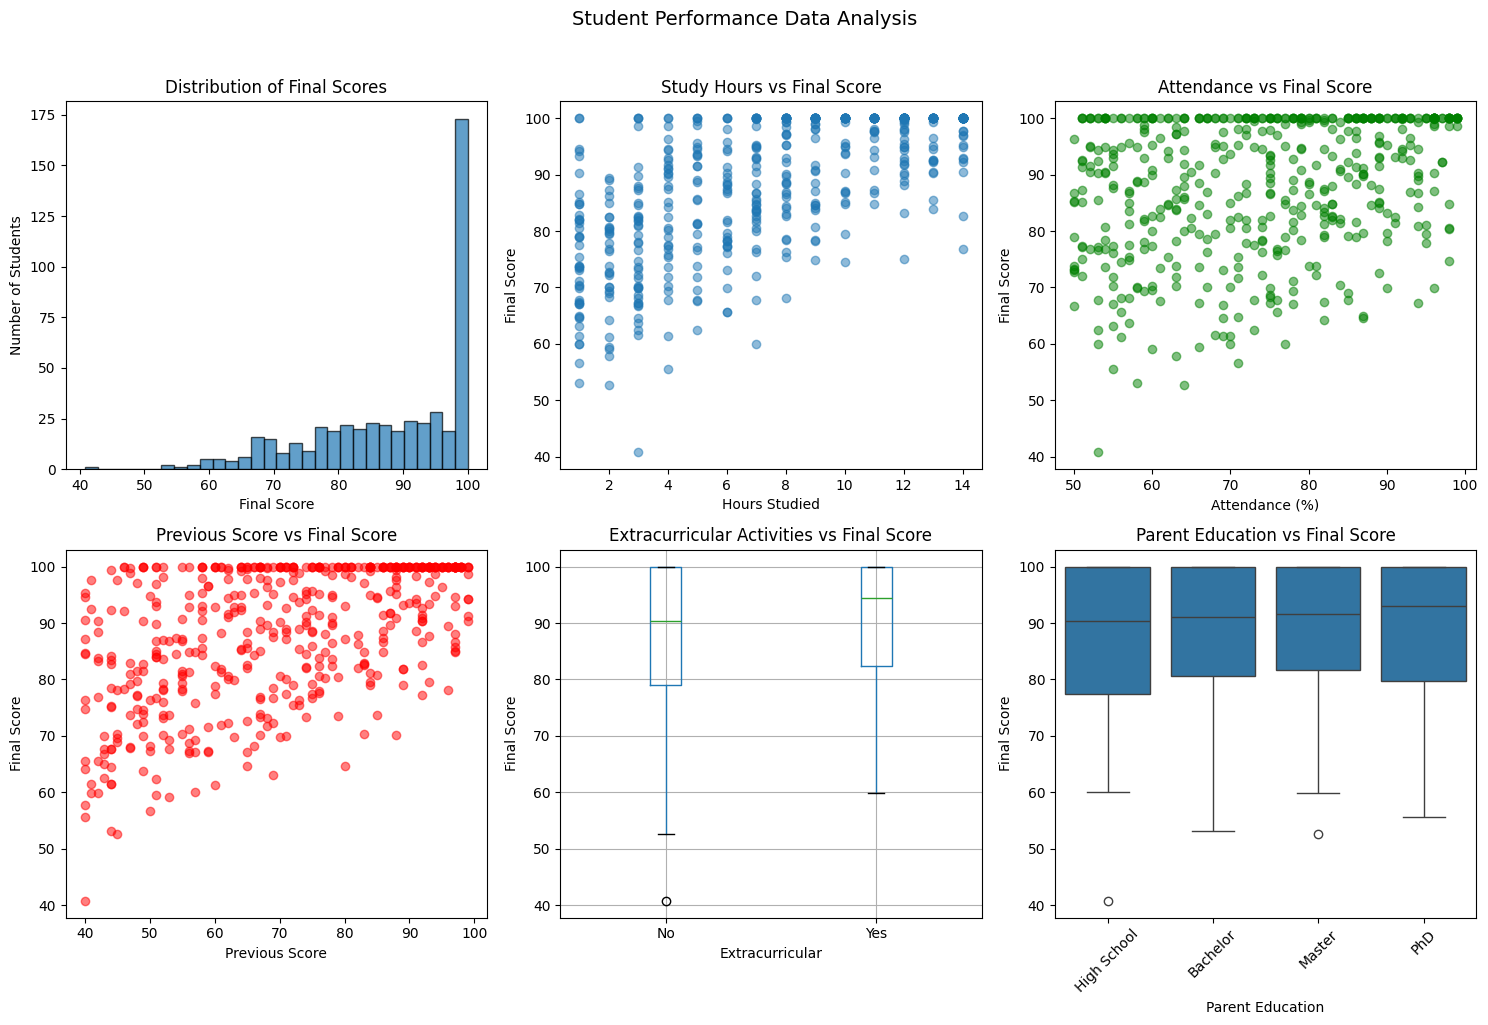


📊 Key Observations from Plots:
1. Final scores roughly follow a normal distribution
2. More study hours generally lead to higher scores
3. Better attendance correlates with better performance
4. Students with extracurricular activities tend to score higher
5. Higher parent education level correlates with better scores


In [ ]:
# pip install matplotlib seaborn

# Create visualizations to understand the data
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# 1. Distribution of final scores
axes[0, 0].hist(df_students['final_score'], bins=30, edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Final Scores', fontsize=12)
axes[0, 0].set_xlabel('Final Score')
axes[0, 0].set_ylabel('Number of Students')

# 2. Study hours vs Final Score
axes[0, 1].scatter(df_students['hours_studied'], df_students['final_score'], alpha=0.5)
axes[0, 1].set_title('Study Hours vs Final Score', fontsize=12)
axes[0, 1].set_xlabel('Hours Studied')
axes[0, 1].set_ylabel('Final Score')

# 3. Attendance vs Final Score
axes[0, 2].scatter(df_students['attendance'], df_students['final_score'], alpha=0.5, color='green')
axes[0, 2].set_title('Attendance vs Final Score', fontsize=12)
axes[0, 2].set_xlabel('Attendance (%)')
axes[0, 2].set_ylabel('Final Score')

# 4. Previous Score vs Final Score
axes[1, 0].scatter(df_students['previous_score'], df_students['final_score'], alpha=0.5, color='red')
axes[1, 0].set_title('Previous Score vs Final Score', fontsize=12)
axes[1, 0].set_xlabel('Previous Score')
axes[1, 0].set_ylabel('Final Score')

# 5. Box plot - Extracurricular vs Final Score
df_students.boxplot(column='final_score', by='extracurricular', ax=axes[1, 1])
axes[1, 1].set_title('Extracurricular Activities vs Final Score', fontsize=12)
axes[1, 1].set_xlabel('Extracurricular')
axes[1, 1].set_ylabel('Final Score')

# 6. Parent Education vs Final Score
education_order = ['High School', 'Bachelor', 'Master', 'PhD']
sns.boxplot(x='parent_education', y='final_score', data=df_students, order=education_order, ax=axes[1, 2])
axes[1, 2].set_title('Parent Education vs Final Score', fontsize=12)
axes[1, 2].set_xlabel('Parent Education')
axes[1, 2].set_ylabel('Final Score')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.suptitle('Student Performance Data Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key Observations from Plots:")
print("1. Final scores roughly follow a normal distribution")
print("2. More study hours generally lead to higher scores")
print("3. Better attendance correlates with better performance")
print("4. Students with extracurricular activities tend to score higher")
print("5. Higher parent education level correlates with better scores")

In [10]:
# pip install scikit-learn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Prepare data for machine learning
print("="*60)
print("PREPARING DATA FOR DAY 2 (MACHINE LEARNING)")
print("="*60)

# 1. Check for missing values
print("\n1. Checking for missing values:")
print(df_students.isnull().sum())

# 2. Convert categorical variables to numbers
print("\n2. Converting categorical variables:")
label_encoders = {}

categorical_cols = ['extracurricular', 'parent_education', 'internet_access']
for col in categorical_cols:
    le = LabelEncoder()
    df_students[col + '_encoded'] = le.fit_transform(df_students[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print("   ", col, ":", mapping)
    label_encoders[col] = le

# 3. Select features for training
feature_cols = ['hours_studied', 'previous_score', 'attendance', 'sleep_hours',
                'extracurricular_encoded', 'internet_access_encoded', 'parent_education_encoded']
target_col = 'final_score'

print("\n3. Features for ML (", len(feature_cols), "features):")
for col in feature_cols:
    print("   -", col)
print("   Target:", target_col)

# 4. Check correlations
print("\n4. Correlation with target (what influences scores most):")
correlations = df_students[feature_cols + [target_col]].corr()[target_col].sort_values(ascending=False)
for feature, corr in correlations.items():
    if feature != target_col:
        print("   ", feature, ":", round(corr, 3))

PREPARING DATA FOR DAY 2 (MACHINE LEARNING)

1. Checking for missing values:
student_id          0
hours_studied       0
previous_score      0
attendance          0
sleep_hours         0
extracurricular     0
parent_education    0
internet_access     0
final_score         0
dtype: int64

2. Converting categorical variables:
    extracurricular : {'No': np.int64(0), 'Yes': np.int64(1)}
    parent_education : {'Bachelor': np.int64(0), 'High School': np.int64(1), 'Master': np.int64(2), 'PhD': np.int64(3)}
    internet_access : {'No': np.int64(0), 'Yes': np.int64(1)}

3. Features for ML ( 7 features):
   - hours_studied
   - previous_score
   - attendance
   - sleep_hours
   - extracurricular_encoded
   - internet_access_encoded
   - parent_education_encoded
   Target: final_score

4. Correlation with target (what influences scores most):
    hours_studied : 0.66
    previous_score : 0.528
    attendance : 0.288
    sleep_hours : 0.176
    extracurricular_encoded : 0.124
    internet_acces

In [ ]:
# Save the processed dataset
df_students.to_csv('student_performance.csv', index=False)
print("✅ Dataset saved as 'student_performance.csv'")

# Also save preprocessed data (ready for ML)
ml_ready_data = df_students[feature_cols + [target_col]]
ml_ready_data.to_csv('student_performance_ml_ready.csv', index=False)
print("✅ ML-ready dataset saved as 'student_performance_ml_ready.csv'")

# Save feature information for Day 2
import json
feature_info = {
    'feature_columns': feature_cols,
    'target_column': target_col,
    'categorical_mappings': {}
}

for col, le in label_encoders.items():
    feature_info['categorical_mappings'][col] = dict(zip(le.classes_, le.transform(le.classes_)))

with open('feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)
print("✅ Feature information saved as 'feature_info.json'")

print("\n📁 Files created for Day 2:")
print("   1. student_performance.csv - Raw dataset")
print("   2. student_performance_ml_ready.csv - Preprocessed for ML")
print("   3. feature_info.json - Feature names and mappings")